## Facial feature positioning

In [1]:
# Cell 1: Imports and Global Template Configuration
import os
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from pathlib import Path

# Define the standard 5-point facial landmark template coordinates
TARGET_LANDMARKS = np.array([
    [75, 125],   # Left eye center
    [125, 125],  # Right eye center
    [100, 160],  # Nose tip
    [80, 180],   # Left mouth corner
    [125, 180]   # Right mouth corner
], dtype=np.float32)

# Define target output canvas size (width, height)
OUTPUT_SIZE = (200, 250)

print("Environment initialized. Target landmarks template loaded.")

Environment initialized. Target landmarks template loaded.


In [2]:
# Cell 2: Geometric Transformation Core Functions

def estimate_similarity_transform(src_pts, dst_pts):
    """
    Estimates a 2x3 similarity transform matrix (scale, rotation, translation)
    using least-squares evaluation.
    """
    # OpenCV partial affine estimation solves for similarity transformation
    T, inliers = cv2.estimateAffinePartial2D(src_pts, dst_pts, method=cv2.LMEDS)
    return T

def estimate_affine_transform(src_pts, dst_pts):
    """
    Estimates a full 2x3 affine transform matrix (6 degrees of freedom).
    """
    T, inliers = cv2.estimateAffine2D(src_pts, dst_pts, method=cv2.LMEDS)
    return T

def apply_transform(pts, T):
    """
    Applies the 2x3 transformation matrix T to an array of 2D points.
    """
    pts_homo = np.hstack([pts, np.ones((pts.shape[0], 1))])
    return pts_homo.dot(T.T)

def warp_image(img, T, dsize=OUTPUT_SIZE):
    """
    Warps the input image using the transformation matrix T with bicubic interpolation.
    """
    img_np = np.array(img)
    warped_np = cv2.warpAffine(img_np, T, dsize, flags=cv2.INTER_CUBIC)
    return Image.fromarray(warped_np)

In [3]:
# Cell 3: Actual MediaPipe Landmark Detection for 5 Points
import mediapipe as mp

class LandmarkDetectionError(Exception):
    """Custom exception class for landmark detection failures."""
    pass

def detect_five_landmarks(image):
    """
    Detects 5 specific facial landmarks using MediaPipe Face Mesh.
    Coordinates are scaled to the actual image dimensions.
    """
    mp_face_mesh = mp.solutions.face_mesh
    img_np = np.array(image)
    h, w, _ = img_np.shape
    
    with mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True, # Enables precise iris and lip tracking
        min_detection_confidence=0.5
    ) as face_mesh:
        
        # Convert RGB to BGR for OpenCV/MediaPipe processing
        results = face_mesh.process(cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR))
        
        if not results.multi_face_landmarks:
            raise LandmarkDetectionError("No face detected in the image.")
        
        landmarks = results.multi_face_landmarks[0].landmark
        
        # Select representative indices for the 5 standard landmarks
        idx_left_eye = 468 if len(landmarks) > 468 else 159
        idx_right_eye = 473 if len(landmarks) > 473 else 386
        idx_nose = 1
        idx_left_mouth = 61
        idx_right_mouth = 291
        
        # Extract and scale coordinates to pixel values
        pts = np.array([
            [landmarks[idx_left_eye].x * w, landmarks[idx_left_eye].y * h],
            [landmarks[idx_right_eye].x * w, landmarks[idx_right_eye].y * h],
            [landmarks[idx_nose].x * w, landmarks[idx_nose].y * h],
            [landmarks[idx_left_mouth].x * w, landmarks[idx_left_mouth].y * h],
            [landmarks[idx_right_mouth].x * w, landmarks[idx_right_mouth].y * h]
        ], dtype=np.float32)
        
        return pts

In [8]:
# Cell 4: Single Image Path Configuration
import os
import sys

print("current working directory:", os.getcwd())

# CHANGE THIS TO YOUR ACTUAL IMAGE FILENAME OR ABSOLUTE PATH
data_path = os.path.join(os.getcwd(), "data", "1.png")  # Example: "test_image.jpg" or "/path/to/your/image.jpg"
IMAGE_PATH = Path(data_path)

if not IMAGE_PATH.exists():
    print(f"Error: Image file not found at '{IMAGE_PATH.absolute()}'.")
    print("Please place your test image in the workspace and update IMAGE_PATH.")
else:
    print(f"Target image '{IMAGE_PATH.name}' successfully verified and ready.")

current working directory: /Users/hawk/workspace/Computer_Vision_Course/Test1
Target image '1.png' successfully verified and ready.


In [9]:
# Cell 5: Single Image Face Alignment Pipeline Execution

if IMAGE_PATH.exists():
    sample_image = Image.open(IMAGE_PATH).convert("RGB")
    
    try:
        # Step 1: Attempt automatic 5-point detection
        src_landmarks = detect_five_landmarks(sample_image)
        print("Successfully extracted 5 landmarks automatically via MediaPipe.")
    except Exception as e:
        print(f"Automatic detection skipped/failed: {e}")
        print("Falling back to manual coordinates. Please adjust the coordinates below:")
        
        # MANUAL INTERFACE: If auto-detection fails, enter your image's 5 landmark coordinates [x, y]
        # Coordinates order: [Left Eye, Right Eye, Nose, Left Mouth Corner, Right Mouth Corner]
        src_landmarks = np.array([
            [120, 140],  # Example Left Eye Center
            [180, 142],  # Example Right Eye Center
            [151, 175],  # Example Nose Tip
            [125, 210],  # Example Left Mouth Corner
            [175, 212]   # Example Right Mouth Corner
        ], dtype=np.float32)
    
    # Step 2: Calculate the 2x3 similarity matrix using least-squares
    T_matrix = estimate_similarity_transform(src_landmarks, TARGET_LANDMARKS)
    
    # Step 3: Map source points to check alignment precision
    mapped_landmarks = apply_transform(src_landmarks, T_matrix)
    
    # Step 4: Compute evaluation metrics (Residual Mean Error)
    mean_error = np.mean(np.linalg.norm(mapped_landmarks - TARGET_LANDMARKS, axis=1))
    
    # Step 5: Warp image using bicubic interpolation onto the standard canvas
    aligned_image = warp_image(sample_image, T_matrix, dsize=OUTPUT_SIZE)
    
    # Step 6: Decompose matrix to extract scale and rotation metrics
    scale = np.sqrt(T_matrix[0, 0]**2 + T_matrix[0, 1]**2)
    rotation_deg = np.degrees(np.arctan2(T_matrix[1, 0], T_matrix[0, 0]))
    
    print("\n" + "="*30 + " ALIGNMENT REPORT " + "="*30)
    print(f"Extracted Transformation Matrix:\n{T_matrix}")
    print(f"Calculated Scale Factor       : {scale:.3f}x")
    print(f"Calculated Rotation Angle     : {rotation_deg:.2f} degrees")
    print(f"Mean Landmark Residual Error  : {mean_error:.4f} pixels")
    print("="*78)

Automatic detection skipped/failed: module 'mediapipe' has no attribute 'solutions'
Falling back to manual coordinates. Please adjust the coordinates below:

============================== ALIGNMENT REPORT ==============================
Extracted Transformation Matrix:
[[  0.81301222   0.03330987 -26.97031022]
 [ -0.03330987   0.81301222  16.07559455]]
Calculated Scale Factor       : 0.814x
Calculated Rotation Angle     : -2.35 degrees
Mean Landmark Residual Error  : 3.1338 pixels


In [1]:
import mediapipe as mp
print(mp.__version__)
print(hasattr(mp, 'solutions')) # 预期输出 True

0.10.35
False


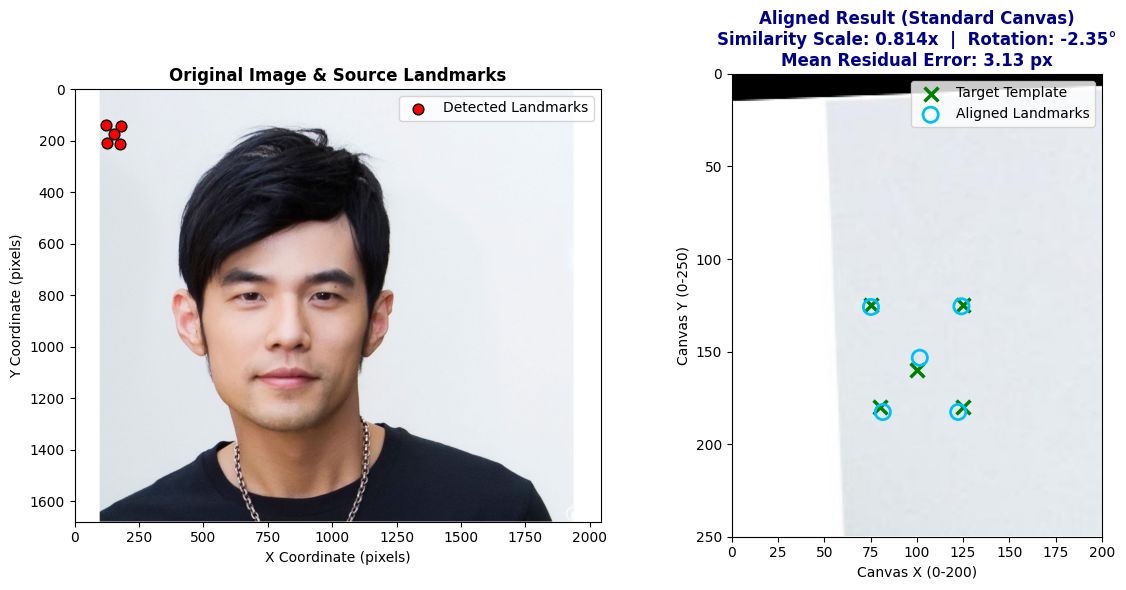

In [10]:
# Cell 6: Comprehensive Visualization and Geometric Verification
import matplotlib.pyplot as plt

# Check if the required alignment variables exist in the current workspace
if 'sample_image' in locals() and 'aligned_image' in locals():
    # Set up a side-by-side figure layout
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # ------------------ Plot 1: Original Image ------------------
    axes[0].imshow(sample_image)
    # Plot the 5 landmarks automatically detected or manually input
    axes[0].scatter(src_landmarks[:, 0], src_landmarks[:, 1], c='red', marker='o', s=60, edgecolors='black', label='Detected Landmarks')
    axes[0].set_title("Original Image & Source Landmarks", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("X Coordinate (pixels)")
    axes[0].set_ylabel("Y Coordinate (pixels)")
    axes[0].axis("on")  # Enable axes to show the original image coordinate space
    axes[0].legend(loc='upper right')
    
    # ------------------ Plot 2: Aligned Image ------------------
    axes[1].imshow(aligned_image)
    # Plot the ideal standard target template points as green 'X'
    axes[1].scatter(TARGET_LANDMARKS[:, 0], TARGET_LANDMARKS[:, 1], c='green', marker='x', s=100, linewidths=2.5, label='Target Template')
    # Plot the actual mapped landmarks as hollow cyan circles to verify overlap accuracy
    axes[1].scatter(mapped_landmarks[:, 0], mapped_landmarks[:, 1], facecolors='none', edgecolors='deepskyblue', s=120, linewidths=2, label='Aligned Landmarks')
    
    # Compose dynamic title based on the computed matrix metrics from previous cell
    metrics_title = (
        f"Aligned Result (Standard Canvas)\n"
        f"Similarity Scale: {scale:.3f}x  |  Rotation: {rotation_deg:.2f}°\n"
        f"Mean Residual Error: {mean_error:.2f} px"
    )
    axes[1].set_title(metrics_title, fontsize=12, fontweight='bold', color='darkblue')
    axes[1].set_xlabel("Canvas X (0-200)")
    axes[1].set_ylabel("Canvas Y (0-250)")
    
    # Set strict limits matching the standard output size template
    axes[1].set_xlim(0, OUTPUT_SIZE[0])
    axes[1].set_ylim(OUTPUT_SIZE[1], 0)  # Invert Y axis to align with computer vision coordinate standards
    axes[1].axis("on")
    axes[1].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: Required alignment variables not found.")
    print("Please ensure you have executed the single image pipeline cell successfully first.")